In [ ]:
from google.colab import files
uploaded = files.upload()
print(uploaded)

Saving Bank_Dataset.csv to Bank_Dataset.csv
{'Bank_Dataset.csv': b"RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,YearsWithBank,Balance,HasCrCard,IsActiveMember,EstimatedSalary\r\n1,15634602,Hargrave,619,France,F,42,2,0,1,1,101348.88\r\n2,15647311,Hill,608,Spain,F,41,1,83807.86,0,1,112542.58\r\n3,15619304,Onio,502,France,Female,42,8,159660.8,1,0,113931.57\r\n4,15701354,Boni,699,France,F,39,1,0,0,0,93826.63\r\n5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,79084.1\r\n6,15574012,Chu,645,Spain,M,44,8,113755.78,1,0,149756.71\r\n7,15592531,Bartlett,822,France,Male,50,7,0,1,1,10062.8\r\n8,15656148,Obinna,376,Germany,f,29,4,115046.74,1,0,119346.88\r\n9,15792365,He,501,France,Male,44,4,142051.07,0,1,74940.5\r\n10,15592389,H?,684,France,Male,27,2,134603.88,1,1,71725.73\r\n11,15767821,Bearce,528,France,m,31,6,102016.72,0,0,80181.12\r\n12,15737173,Andrews,497,Spain,Male,24,3,0,1,0,76390.01\r\n13,15632264,Kay,476,France,Fem,34,10,0,1,0,26260.98\r\n14,15691483,Chin,549,Franc

In [ ]:
import pandas as pd
df = pd.read_csv('Bank_Dataset.csv')
print(df)

     RowNumber  CustomerId     Surname  CreditScore Geography  Gender  Age  \
0            1    15634602    Hargrave          619    France       F   42   
1            2    15647311        Hill          608     Spain       F   41   
2            3    15619304        Onio          502    France  Female   42   
3            4    15701354        Boni          699    France       F   39   
4            5    15737888    Mitchell          850     Spain  Female   43   
..         ...         ...         ...          ...       ...     ...  ...   
995        996    15810218         Sun          610     Spain    Male   29   
996        997    15645621      Hunter          811     Spain    Male   44   
997        998    15608114     Manfrin          587     Spain    Male   62   
998        999    15659557  Artamonova          811   Germany  Female   28   
999       1000    15787772      Hansen          759    France       F   38   

     YearsWithBank    Balance  HasCrCard  IsActiveMember  Estim

Preprocessing

In [ ]:
#fix inconsistant column
df['Gender'] = df['Gender'].str.lower().replace({
    'f': 'Female',
    'F': 'Female',
    'Fem': 'Female',
    'fem': 'Female',
    'fe': 'Female',
    'Fe': 'Female',
    'female': 'Female',
    'm': 'Male',
     'M': 'Male',
    'm': 'Male',
    'mal': 'Male',
    'Mal': 'Male',
    'male': 'Male'
})

In [ ]:
# Check unique values to make sure that the gender column is consistant
print("Unique Gender values:", df['Gender'].unique())

Unique Gender values: ['Female' 'Male']


In [ ]:
#check the uniqueness of the geography column
print("Unique Geography values:", df['Geography'].unique())

Unique Geography values: ['France' 'Spain' 'Germany']


In [ ]:
#Encode Gender
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [ ]:
# Encode Geography
df['Geography'] = df['Geography'].map({'France': 0, 'Spain': 1, 'Germany': 2})

In [ ]:
#check for missing columns
print("Missing values per column:\n", df.isnull().sum())

Missing values per column:
 RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
YearsWithBank      0
Balance            0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
dtype: int64


In [ ]:
# Checking for outliers in the numerical columns
import pandas as pd

# Numeric columns to check
numeric_cols = ['CreditScore', 'Age', 'YearsWithBank', 'Balance', 'EstimatedSalary']

# DataFrame to store outlier flags (True = outlier)
outlier_flags = pd.DataFrame(False, index=df.index, columns=numeric_cols)

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Mark outliers
    outlier_flags[col] = (df[col] < lower_bound) | (df[col] > upper_bound)

# Rows with at least one outlier
rows_with_outliers = df[outlier_flags.any(axis=1)].copy()

# Add a column listing which fields are outliers
rows_with_outliers["Outlier_Columns"] = outlier_flags[outlier_flags.any(axis=1)].apply(
    lambda x: [col for col in x.index if x[col]], axis=1
)

# Show results
print(f"Total rows with outliers: {len(rows_with_outliers)}\n")
print(rows_with_outliers[["Outlier_Columns"] + numeric_cols])

Total rows with outliers: 34

    Outlier_Columns  CreditScore  Age  YearsWithBank    Balance  \
58            [Age]          511   66              4       0.00   
85            [Age]          652   75             10       0.00   
104           [Age]          670   65              1       0.00   
158           [Age]          646   73              6   97259.25   
181           [Age]          510   65              2       0.00   
230           [Age]          673   72              1       0.00   
234           [Age]          585   67              5  113978.97   
243           [Age]          659   67              6  117411.60   
252           [Age]          681   79              0       0.00   
310           [Age]          652   80              4       0.00   
364           [Age]          640   68              9       0.00   
371           [Age]          640   75              1  106307.91   
385           [Age]          560   66              9       0.00   
399           [Age]          616

When we used the IQR rule, only the "Age" column had values outside the normal range in your dataset.

That means things like "CreditScore", "Balance", or "EstimatedSalary" didn’t have values extreme enough to be flagged

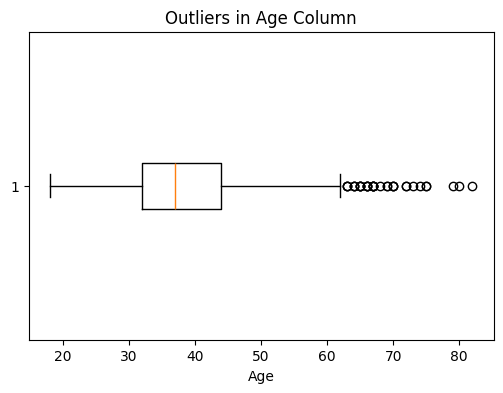

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.boxplot(df['Age'], vert=False)
plt.title('Outliers in Age Column')
plt.xlabel('Age')
plt.show()

there are a lot of extreeme outliers in the age

In [ ]:
# Remove rows with extreme Age values
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

In [ ]:
# Recalculate bounds directly before filtering
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print(lower_bound, upper_bound)  # See your cutoff values

# Filter
df = df[(df['Age'] >= lower_bound) & (df['Age'] <= upper_bound)]

# Check shape
print(df.shape)

14.0 62.0
(966, 12)


In [ ]:
#feature engineering
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1e-5)
#Compares how much money the customer has in their account (Balance) relative to their income (EstimatedSalary).
#A higher value means the person keeps more of their salary as balance — could suggest saving habits.
#A lower value means they spend most of their salary quickly — could suggest higher spending or low savings

df['LoyaltyRatio'] = df['YearsWithBank'] / (df['Age'] + 1e-5)
#Measures what percentage of their life they’ve been with the bank.
#If someone is 40 years old and has been with the bank for 20 years → ratio = 0.5 (half their life).
#A higher ratio might indicate stronger loyalty or long-term relationship with the bank

In [ ]:
#Scale Numerical Features
import numpy as np
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include=np.number).columns
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

Puts all features on the same scale → prevents large-valued features (like EstimatedSalary) from dominating small-valued ones (like BalanceSalaryRatio) in distance-based or gradient-based models.

Improves model stability → prevents numerical issues where huge differences in scale cause unstable or exploding weights.

Preserves data relationships → it changes the unit of measurement but not the underlying patterns, so accuracy of relationships stays intact

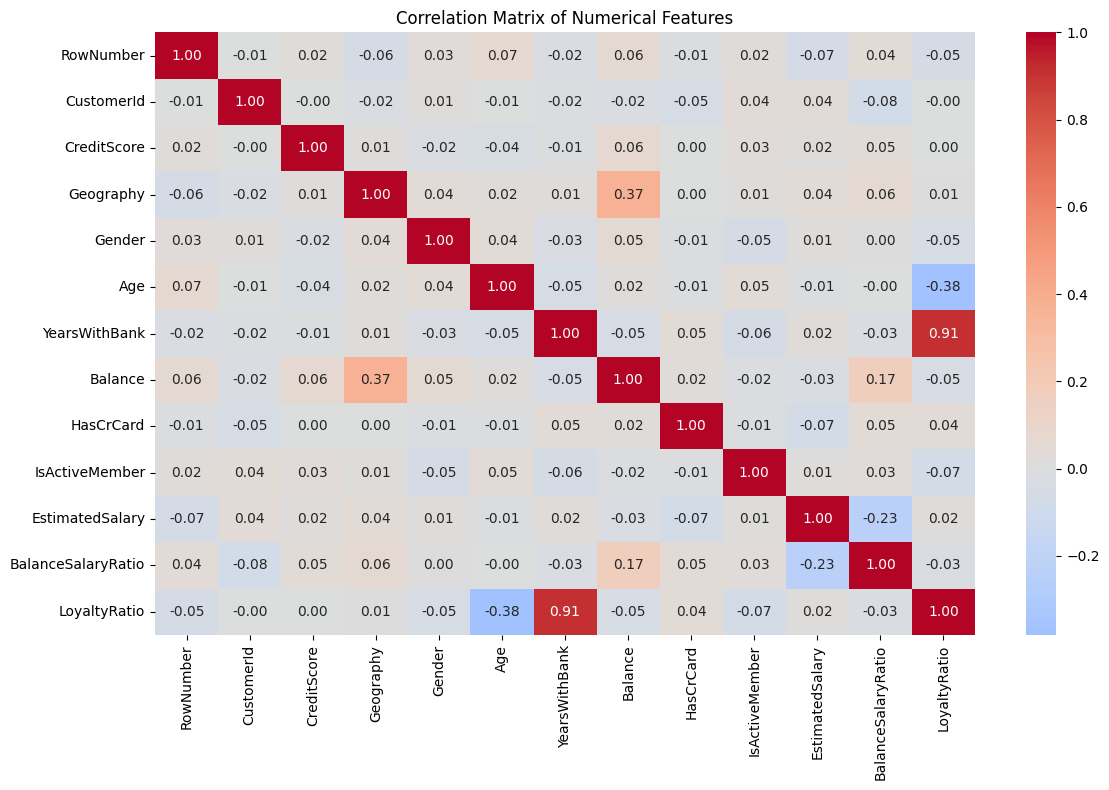

In [ ]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
# Calculate correlation matrix for numerical features
corr_matrix = df.select_dtypes(include=np.number).corr()
# Create a heatmap
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

Unsupervised

In [ ]:
print(df)

     RowNumber  CustomerId     Surname  CreditScore  Geography    Gender  \
0    -1.726079   -0.795018    Hargrave    -0.303184  -0.938072  1.077531   
1    -1.722607   -0.618111        Hill    -0.414578   0.260576  1.077531   
2    -1.719136   -1.007965        Onio    -1.488014  -0.938072  1.077531   
3    -1.715664    0.134161        Boni     0.506956  -0.938072  1.077531   
4    -1.712193    0.642710    Mitchell     2.036096   0.260576  1.077531   
..         ...         ...         ...          ...        ...       ...   
995   1.727998    1.649535         Sun    -0.394325   0.260576 -0.928047   
996   1.731469   -0.641635      Hunter     1.641153   0.260576 -0.928047   
997   1.734941   -1.163728     Manfrin    -0.627240   0.260576 -0.928047   
998   1.738412   -0.447648  Artamonova     1.641153   1.459223  1.077531   
999   1.741884    1.337090      Hansen     1.114561  -0.938072  1.077531   

          Age  YearsWithBank   Balance  HasCrCard  IsActiveMember  \
0    0.447656     

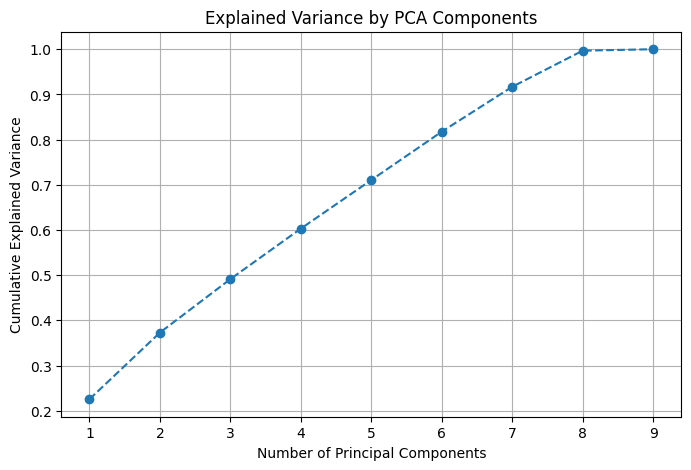

Original shape: (966, 9)
Reduced shape after PCA: (966, 8)


In [ ]:
#PCA’s goal: reduce redundancy and find patterns
#If we keep IDs, PCA would get meaningless noise (IDs don’t represent behavior).
#If we keep categorical text, PCA can’t handle it.
#The behavioral/financial features (balance, credit score, age, etc.) are what actually separate customers into groups

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Drop identifiers + categorical columns (Gender, Geography)
df_pca = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Gender', 'Geography'])
#they don’t describe customer behavior, just IDs
#already encoded but not very useful for PCA because they don’t explain variance in the same way numerical continuous features do

# 2. Run PCA with all components first
pca = PCA(n_components=None)
X_pca = pca.fit_transform(df_pca)

# 3. Explained variance analysis
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(explained_variance)+1), cumulative_variance, marker='o', linestyle='--')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

# 4. Keep enough components to explain 95% variance
pca = PCA(n_components=0.95)
X_pca = pca.fit_transform(df_pca)

print("Original shape:", df_pca.shape)
print("Reduced shape after PCA:", X_pca.shape)

In [ ]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Drop identifiers and categorical variables we decided not to keep
df_pca = df.drop(columns=['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Gender'])

# Scale the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_pca)

# Run PCA
pca = PCA()
pca.fit(df_scaled)

# Create a DataFrame for loadings (feature contributions to each PC)
loadings = pd.DataFrame(
    pca.components_.T,  # transpose to align features with PCs
    columns=[f'PC{i+1}' for i in range(len(df_pca.columns))],
    index=df_pca.columns
)

# Variance explained
explained_variance = pca.explained_variance_ratio_

print("Explained Variance Ratio:", explained_variance)
print("\nLoadings (Feature contributions):")
print(loadings.round(3))

Explained Variance Ratio: [0.22553653 0.14740092 0.11840863 0.11170276 0.10748128 0.10700769
 0.09930785 0.07991412 0.00324021]

Loadings (Feature contributions):
                      PC1    PC2    PC3    PC4    PC5    PC6    PC7    PC8  \
CreditScore        -0.004  0.153  0.720  0.080  0.297  0.074  0.596 -0.056   
Age                -0.295 -0.060 -0.296  0.268 -0.347  0.618  0.433  0.032   
YearsWithBank       0.641  0.033 -0.081  0.172 -0.201  0.244  0.143 -0.001   
Balance            -0.074  0.411  0.354 -0.270 -0.293  0.458 -0.443 -0.368   
HasCrCard           0.053  0.263 -0.291  0.076  0.787  0.432 -0.166  0.057   
IsActiveMember     -0.103 -0.007  0.204  0.893 -0.016 -0.093 -0.356 -0.120   
EstimatedSalary     0.038 -0.549  0.368 -0.084  0.022  0.363 -0.292  0.581   
BalanceSalaryRatio -0.054  0.656  0.011  0.070 -0.199 -0.131 -0.010  0.710   
LoyaltyRatio        0.692  0.049  0.024  0.063 -0.071  0.009 -0.017 -0.023   

                      PC9  
CreditScore         0.002  


PC1 = Loyalty & Years with Bank

PC2 = Financial Behavior (Balance vs Salary)

PC3 = Creditworthiness

PC4 = Customer Activity

PC5 = Credit Card Usage

PCs 6–9 = smaller patterns/noise

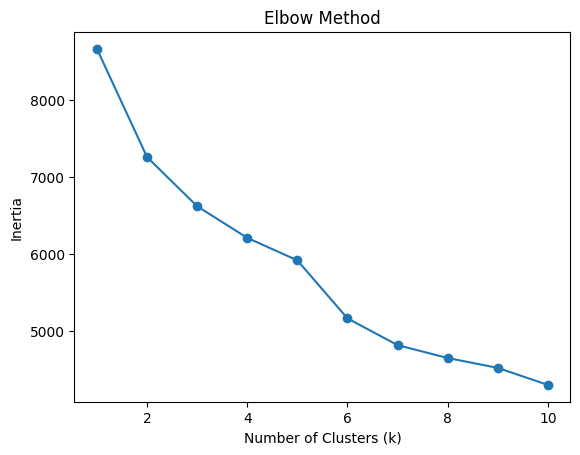

In [ ]:
from sklearn.cluster import KMeans

# Store inertia values
inertia = []

# Try k = 1 to 10
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_pca)
    inertia.append(kmeans.inertia_)

import matplotlib.pyplot as plt

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
from sklearn.cluster import KMeans

# Run KMeans with 5 clusters on the first 7 PCs
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_pca[:, :7])  # use only the first 7 PCs

# Add the cluster labels back to your DataFrame
df_clusters = pd.DataFrame(X_pca[:, :7], columns=[f'PC{i+1}' for i in range(7)])
df_clusters['Cluster'] = clusters

Cluster
0    519
1    447
Name: count, dtype: int64
         CreditScore  Geography    Gender       Age  YearsWithBank   Balance  \
Cluster                                                                        
0           0.000989   0.041170  0.041895  0.183142      -0.784366  0.062796   
1          -0.001149  -0.047801 -0.048644 -0.212641       0.910706 -0.072911   

         HasCrCard  IsActiveMember  EstimatedSalary  BalanceSalaryRatio  \
Cluster                                                                   
0        -0.071311        0.064160         0.004807            0.024879   
1         0.082798       -0.074495        -0.005582           -0.028887   

         LoyaltyRatio  
Cluster                
0           -0.768601  
1            0.892403  


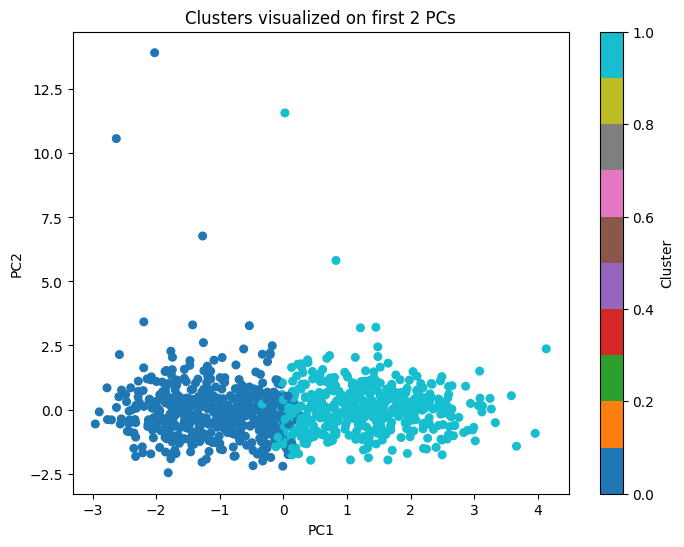

In [ ]:
print(df_clusters['Cluster'].value_counts())

# 6. Add clusters back to original data
df_with_clusters = df.copy()
df_with_clusters['Cluster'] = clusters
cluster_summary = df_with_clusters.drop(columns=['RowNumber','CustomerId']).groupby('Cluster').mean(numeric_only=True)
print(cluster_summary)

import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='tab10', s=30)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Clusters visualized on first 2 PCs')
plt.colorbar(label='Cluster')
plt.show()

Cluster 0 (519 customers):

Older customers
Shorter relationship with bank (newer)
Higher balance, higher balance-to-salary ratio
Slightly more active, but much less loyal
Persona: “Older High-Balance but Low-Loyalty Customers”

Cluster 1 (447 customers):
Younger customers
Long relationship with bank (loyal)
Lower balance
Slightly less active, but strong loyalty
Persona: “Younger Low-Balance but High-Loyalty Customers


Cluster 0 (519 customers)

Age: Above average (positive 0.18) → Slightly older customers.

Years with Bank: Very low (-0.78) → Newer customers.

Balance: Slightly above average.

Estimated Salary: Average.

Balance-Salary Ratio: Slightly above average.

Loyalty Ratio: Very low (-0.76).

Active Membership: Slightly above average.

Profile:
Younger customers in terms of bank relationship (new to the bank, not very loyal yet), but they tend to keep a balance and are a bit more active than average.

Cluster 1 (447 customers)

Age: Below average (-0.21) → Slightly younger customers.

Years with Bank: Very high (0.91) → Long-term customers.

Balance: Slightly below average.

Estimated Salary: Average.

Balance-Salary Ratio: Slightly below average.

Loyalty Ratio: Very high (0.89).

Active Membership: Slightly below average.

Profile:
Older in terms of bank relationship (loyal, long-term customers), but less active and keep lower balances

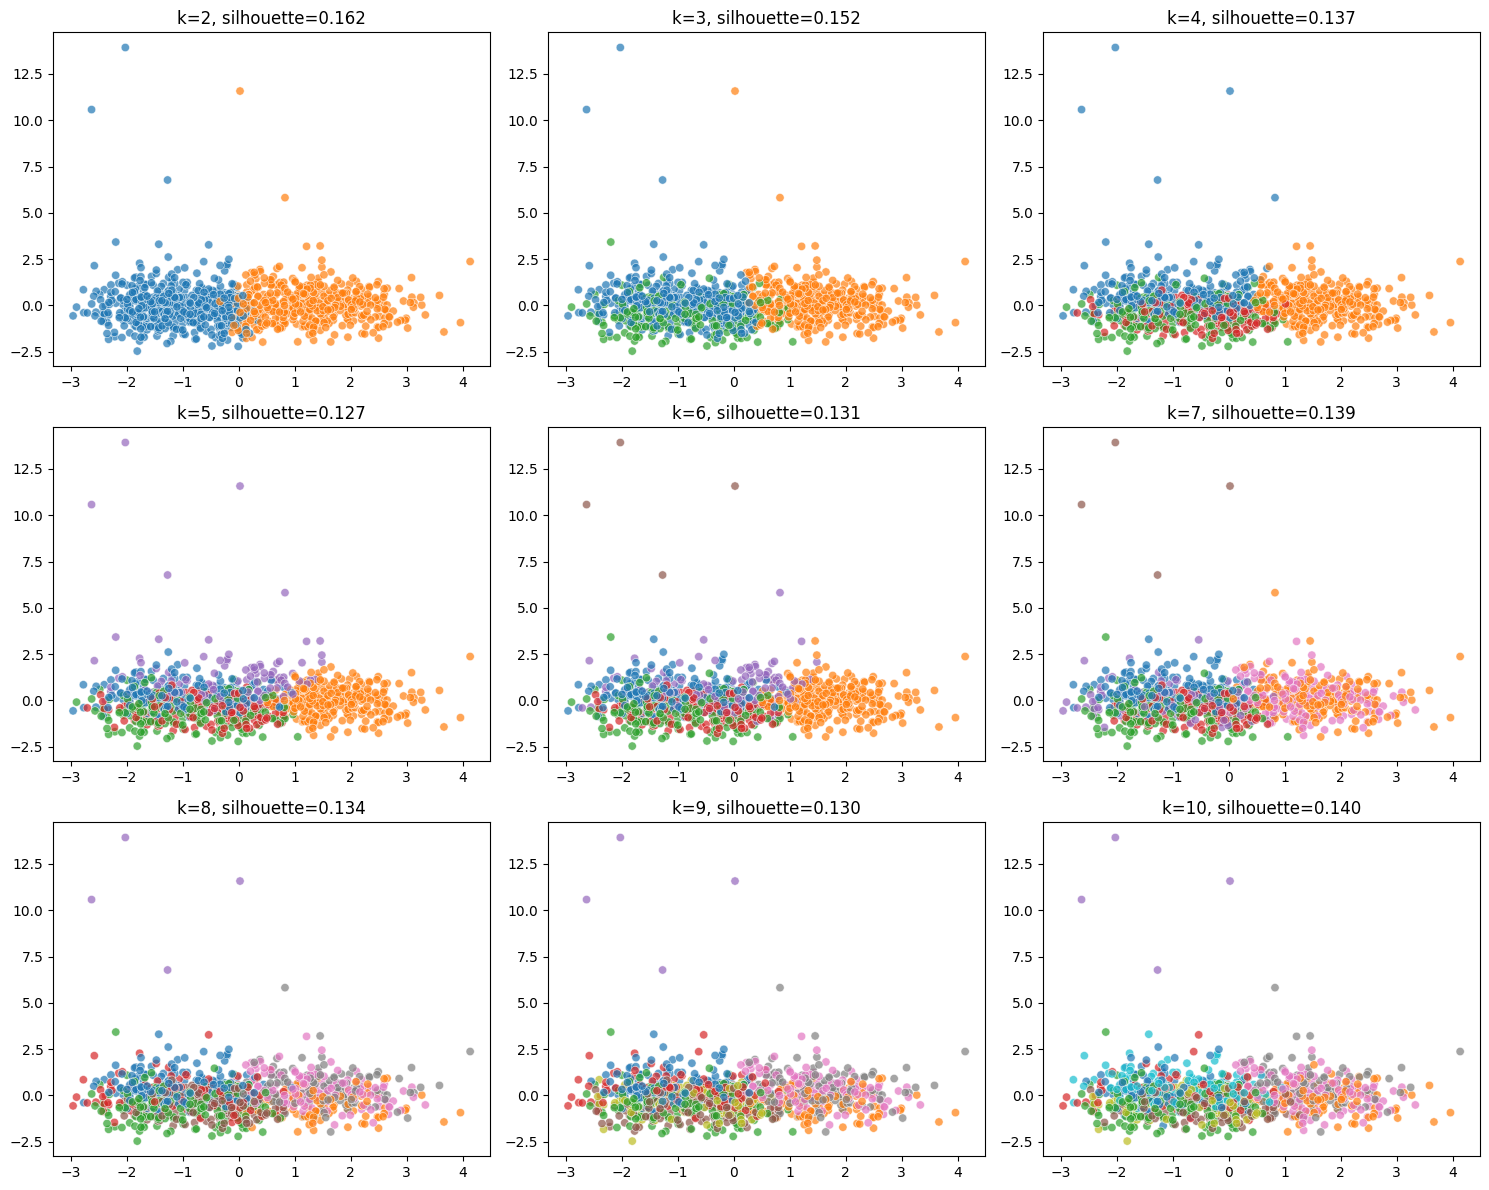

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans

fig, axes = plt.subplots(3, 3, figsize=(15,12))

for i, k in enumerate(range(2, 11)):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)

    ax = axes[i//3, i%3]
    sns.scatterplot(
        x=X_pca[:,0],
        y=X_pca[:,1],
        hue=labels,
        palette="tab10",
        alpha=0.7,
        ax=ax,
        legend=False
    )
    ax.set_title(f"k={k}, silhouette={score:.3f}")

plt.tight_layout()
plt.show()